# CampusPulse — Complaint Pattern & Recurring Issue Detection

This notebook implements:
- K-Means clustering
- Elbow Method
- Silhouette Score
- Hierarchical/Agglomerative Clustering
- DBSCAN

The notebook uses the **final processed CampusPulse dataset** and keeps clustering preprocessing separate from the classification preprocessing.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Robust project-root detection
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "campuspulse_akgec_processed.csv"

RANDOM_STATE = 42
SAMPLE_SIZE = 5000

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)


Project root: c:\Users\acer\Documents\FinalTask\CampusPulse
Dataset: c:\Users\acer\Documents\FinalTask\CampusPulse\data\processed\campuspulse_akgec_processed.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nPriority distribution:")
print(df["priority"].value_counts())


Dataset shape: (200000, 41)

Priority distribution:
priority
Medium      70197
Low         68808
High        42242
Critical    18753
Name: count, dtype: int64


## Clustering Features

These are the nine numerical features used specifically for complaint-pattern detection. The classification preprocessor/PCA is intentionally not reused here because clustering needs its own feature scaling and dimensionality reduction.


In [4]:
pca_features = [
    "affected_users",
    "issue_duration_hours",
    "previous_similar_complaints",
    "complaints_last_7_days",
    "complaints_last_30_days",
    "recurrence_count",
    "equipment_age_years",
    "infrastructure_age_years",
    "estimated_repair_cost",
]

missing = [col for col in pca_features if col not in df.columns]
if missing:
    raise ValueError(f"Missing clustering features: {missing}")

X_cluster = df[pca_features].copy()
X_cluster = X_cluster.fillna(X_cluster.median())

print("Clustering input:", X_cluster.shape)


Clustering input: (200000, 9)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Preserve the original notebook's six-component clustering representation.
cluster_pca = PCA(n_components=6, random_state=RANDOM_STATE)
X_pca = cluster_pca.fit_transform(X_scaled)

print("After scaling:", X_scaled.shape)
print("After PCA    :", X_pca.shape)
print(
    "Variance retained:",
    round(cluster_pca.explained_variance_ratio_.sum(), 4),
)


After scaling: (200000, 9)
After PCA    : (200000, 6)
Variance retained: 0.8901


## K-Means — Elbow Method

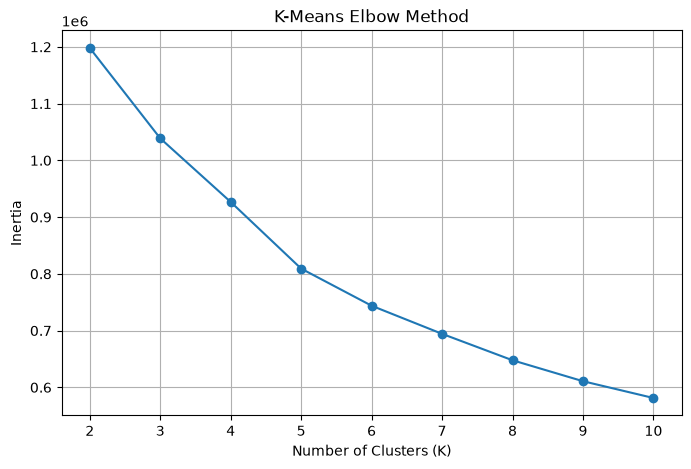

In [ ]:
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10,)
    model.fit(X_pca)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.grid()
plt.show()


## K-Means — Silhouette Score

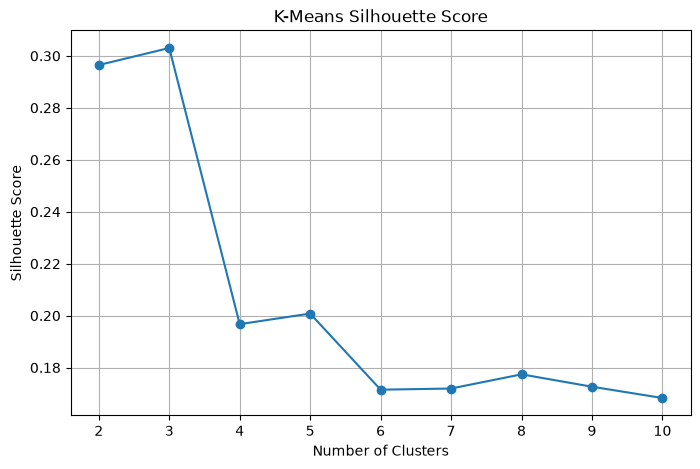

Best silhouette K: 3
Best silhouette score: 0.303


In [7]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10,)
    clusters = model.fit_predict(X_pca)

    score = silhouette_score(X_pca,clusters,sample_size=min(20000, len(X_pca)),random_state=RANDOM_STATE,)

    silhouette_scores.append(score)

best_k = range(2, 11)[int(np.argmax(silhouette_scores))]

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.grid()
plt.show()

print("Best silhouette K:", best_k)
print("Best silhouette score:", round(max(silhouette_scores), 4))


## Final K-Means

The original analysis used **K = 3**, so we retain K=3 for the final pattern interpretation and comparison.


In [9]:
kmeans = KMeans(n_clusters=3,random_state=RANDOM_STATE,n_init=10,)

kmeans_clusters = kmeans.fit_predict(X_pca)

kmeans_df = df.copy()
kmeans_df["cluster"] = kmeans_clusters

print("Cluster sizes:")
print(kmeans_df["cluster"].value_counts().sort_index())

print("\nCluster profile:")
print(
    kmeans_df.groupby("cluster")[pca_features]
    .mean()
    .round(2)
)


Cluster sizes:
cluster
0     68326
1    129918
2      1756
Name: count, dtype: int64

Cluster profile:
         affected_users  issue_duration_hours  previous_similar_complaints  \
cluster                                                                      
0                 79.39                 37.69                         3.31   
1                 77.28                 22.62                         1.13   
2               3341.45                 28.84                         1.89   

         complaints_last_7_days  complaints_last_30_days  recurrence_count  \
cluster                                                                      
0                          1.48                     4.54              4.89   
1                          0.37                     1.61              1.53   
2                          0.74                     2.66              2.64   

         equipment_age_years  infrastructure_age_years  estimated_repair_cost  
cluster                            

## Hierarchical Clustering

In [ ]:
# Random sampling avoids results depending on the original row order.
sample_indices = df.sample(n=min(SAMPLE_SIZE, len(df)),random_state=RANDOM_STATE,).index

hierarchical_sample = X_pca[df.index.get_indexer(sample_indices)]

hierarchical = AgglomerativeClustering(n_clusters=3,)

hierarchical_clusters = hierarchical.fit_predict(hierarchical_sample)

hierarchical_score = silhouette_score(hierarchical_sample,hierarchical_clusters,)

hierarchical_df = df.loc[sample_indices].copy()
hierarchical_df["cluster"] = hierarchical_clusters

print("Sample size:", len(hierarchical_df))
print("Cluster sizes:")
print(pd.Series(hierarchical_clusters).value_counts().sort_index())
print("Silhouette Score:", round(hierarchical_score, 4))

print("\nCluster profile:")
print(
    hierarchical_df.groupby("cluster")[pca_features]
    .mean()
    .round(2)
)


Sample size: 5000
Cluster sizes:
0    2498
1    2458
2      44
Name: count, dtype: int64
Silhouette Score: 0.2224

Cluster profile:
         affected_users  issue_duration_hours  previous_similar_complaints  \
cluster                                                                      
0                 78.12                 38.18                         2.81   
1                 70.62                 18.16                         0.98   
2               3155.84                 25.56                         1.86   

         complaints_last_7_days  complaints_last_30_days  recurrence_count  \
cluster                                                                      
0                          1.22                     3.80              4.06   
1                          0.29                     1.42              1.29   
2                          0.76                     2.50              2.43   

         equipment_age_years  infrastructure_age_years  estimated_repair_cost  
cluste

### Hierarchical Clustering Interpretation

Use the cluster profiles above to identify:
- less recurring/lower-cost complaints
- highly recurring and longer-duration complaints
- high-impact complaints affecting many users with higher repair costs

These labels should only be retained if the rerun profiles support them.


## DBSCAN

In [11]:
dbscan_input = hierarchical_sample

dbscan_scaler = StandardScaler()
dbscan_scaled = dbscan_scaler.fit_transform(dbscan_input)

dbscan = DBSCAN( eps=1.5, min_samples=5,)

dbscan_clusters = dbscan.fit_predict(dbscan_scaled)

print("Cluster sizes:")
print(pd.Series(dbscan_clusters).value_counts().sort_index())


Cluster sizes:
-1     132
 0    4868
Name: count, dtype: int64


In [12]:
mask = dbscan_clusters != -1
unique_non_noise = np.unique(dbscan_clusters[mask])

if len(unique_non_noise) >= 2:
    dbscan_score = silhouette_score(
        dbscan_scaled[mask],
        dbscan_clusters[mask],
    )
    print("Silhouette Score (excluding noise):", round(dbscan_score, 4))
else:
    dbscan_score = np.nan
    print("Silhouette Score cannot be calculated: fewer than two non-noise clusters.")

dbscan_df = df.loc[sample_indices].copy()
dbscan_df["cluster"] = dbscan_clusters

print("\nDBSCAN cluster profile:")
print(
    dbscan_df.groupby("cluster")[pca_features]
    .mean()
    .round(2)
)


Silhouette Score cannot be calculated: fewer than two non-noise clusters.

DBSCAN cluster profile:
         affected_users  issue_duration_hours  previous_similar_complaints  \
cluster                                                                      
-1              1123.13                122.50                         2.50   
 0                73.82                 25.66                         1.89   

         complaints_last_7_days  complaints_last_30_days  recurrence_count  \
cluster                                                                      
-1                         1.11                     3.58              3.70   
 0                         0.75                     2.59              2.65   

         equipment_age_years  infrastructure_age_years  estimated_repair_cost  
cluster                                                                        
-1                      8.91                     14.28               68828.83  
 0                      6.06       

## Final Pattern Summary

Compare the three methods using:
- cluster structure
- cluster sizes
- silhouette score where applicable
- feature means/profile of each cluster

The objective is to identify **similar complaints and recurring campus issue patterns**, which can later support maintenance intelligence and intelligent complaint prioritization.
